In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import datetime
print("Libraries imported successfully! ✅")

Libraries imported successfully! ✅


In [2]:
tickers = ['AAPL', 'GOOGL', 'MSFT', 'TSLA']
df = yf.download(tickers, period='2y', auto_adjust=True)['Close']
print("Stock data downloaded successfully! ✅")
print(f"Date range: {df.index[0].date()} to {df.index[-1].date()}")
print(f"Total trading days: {len(df)}")
print("\nFirst 5 rows:")
print(df.head())

[*********************100%***********************]  4 of 4 completed

1 Failed download:
['MSFT']: OperationalError('database is locked')


Stock data downloaded successfully! ✅
Date range: 2024-05-08 to 2026-05-07
Total trading days: 501

First 5 rows:
Ticker            AAPL       GOOGL  MSFT        TSLA
Date                                                
2024-05-08  181.091919  167.991577   NaN  174.720001
2024-05-09  182.905411  168.566788   NaN  171.970001
2024-05-10  181.645157  167.267532   NaN  168.470001
2024-05-13  184.850342  167.753540   NaN  171.889999
2024-05-14  185.991547  168.943695   NaN  177.550003


In [3]:
df = df.drop(columns=['MSFT'])
df = df.dropna()
print("Data cleaned! ✅")
print(f"Companies: {df.columns.tolist()}")
print(f"Total trading days: {len(df)}")
print(f"Date range: {df.index[0].date()} to {df.index[-1].date()}")

Data cleaned! ✅
Companies: ['AAPL', 'GOOGL', 'TSLA']
Total trading days: 501
Date range: 2024-05-08 to 2026-05-07


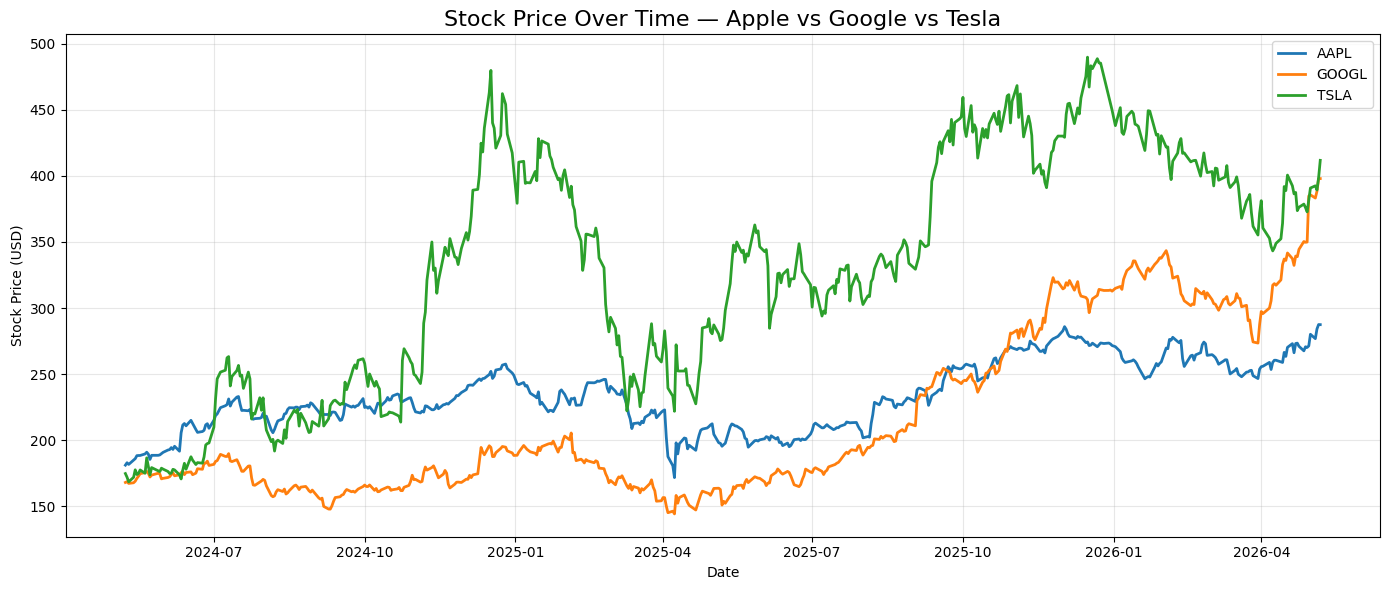

In [4]:
plt.figure(figsize=(14, 6))
for company in df.columns:
    plt.plot(df.index, df[company], label=company, linewidth=2)
plt.title('Stock Price Over Time — Apple vs Google vs Tesla', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('stock_prices.png', dpi=150)
plt.show()

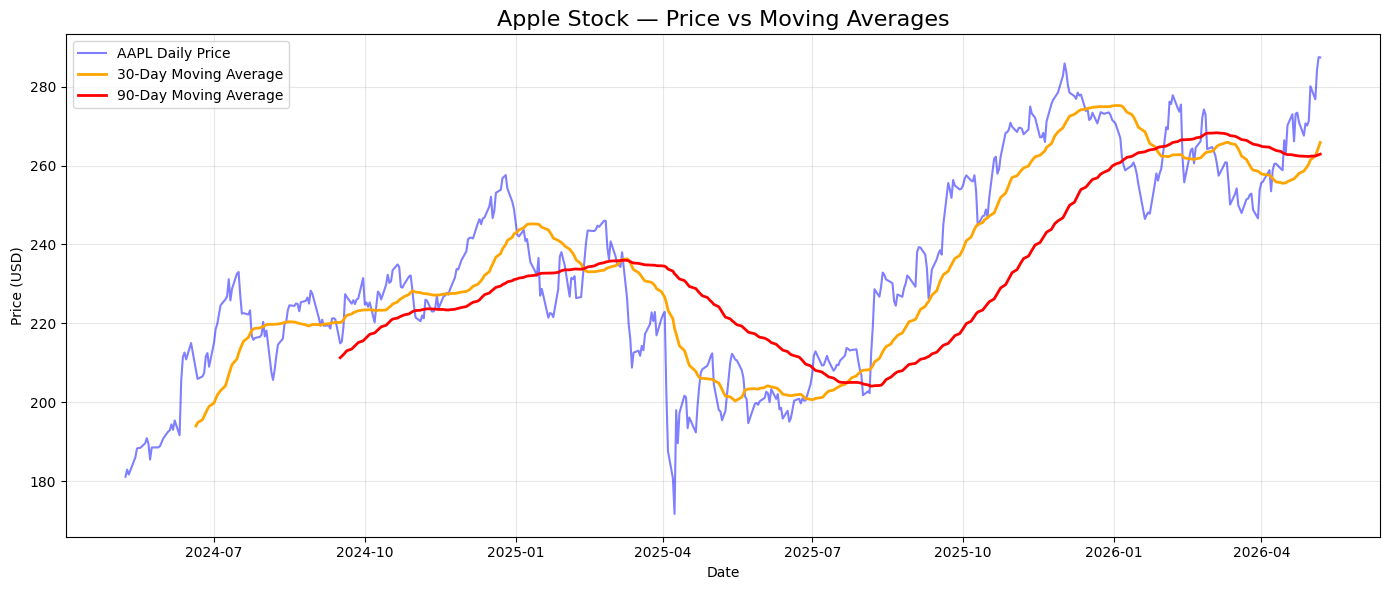

In [5]:
apple = df['AAPL'].copy()
apple_ma30 = apple.rolling(window=30).mean()   
apple_ma90 = apple.rolling(window=90).mean()   
plt.figure(figsize=(14, 6))
plt.plot(apple.index, apple, label='AAPL Daily Price', 
         alpha=0.5, color='blue')
plt.plot(apple_ma30.index, apple_ma30, label='30-Day Moving Average', 
         color='orange', linewidth=2)
plt.plot(apple_ma90.index, apple_ma90, label='90-Day Moving Average', 
         color='red', linewidth=2)
plt.title('Apple Stock — Price vs Moving Averages', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('moving_average.png', dpi=150)
plt.show()

In [6]:
daily_returns = df.pct_change().dropna() * 100
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
colors = ['blue', 'orange', 'green']
companies = ['AAPL', 'GOOGL', 'TSL
for i, (company, color) in enumerate(zip(companies, colors)):
    axes[i].fill_between(daily_returns.index, 
                          daily_returns[company], 
                          color=color, alpha=0.5)
    axes[i].set_title(f'{company} — Daily Returns (%)')
    axes[i].set_ylabel('Return (%)')
    axes[i].axhline(y=0, color='black', linewidth=1)
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('daily_returns.png', dpi=150)
plt.show()
print("Volatility (Standard Deviation of Daily Returns):")
print(daily_returns.std().round(2))
print("\nAverage Daily Return (%):")
print(daily_returns.mean().round(3))

SyntaxError: unterminated string literal (detected at line 4) (1142054882.py, line 4)

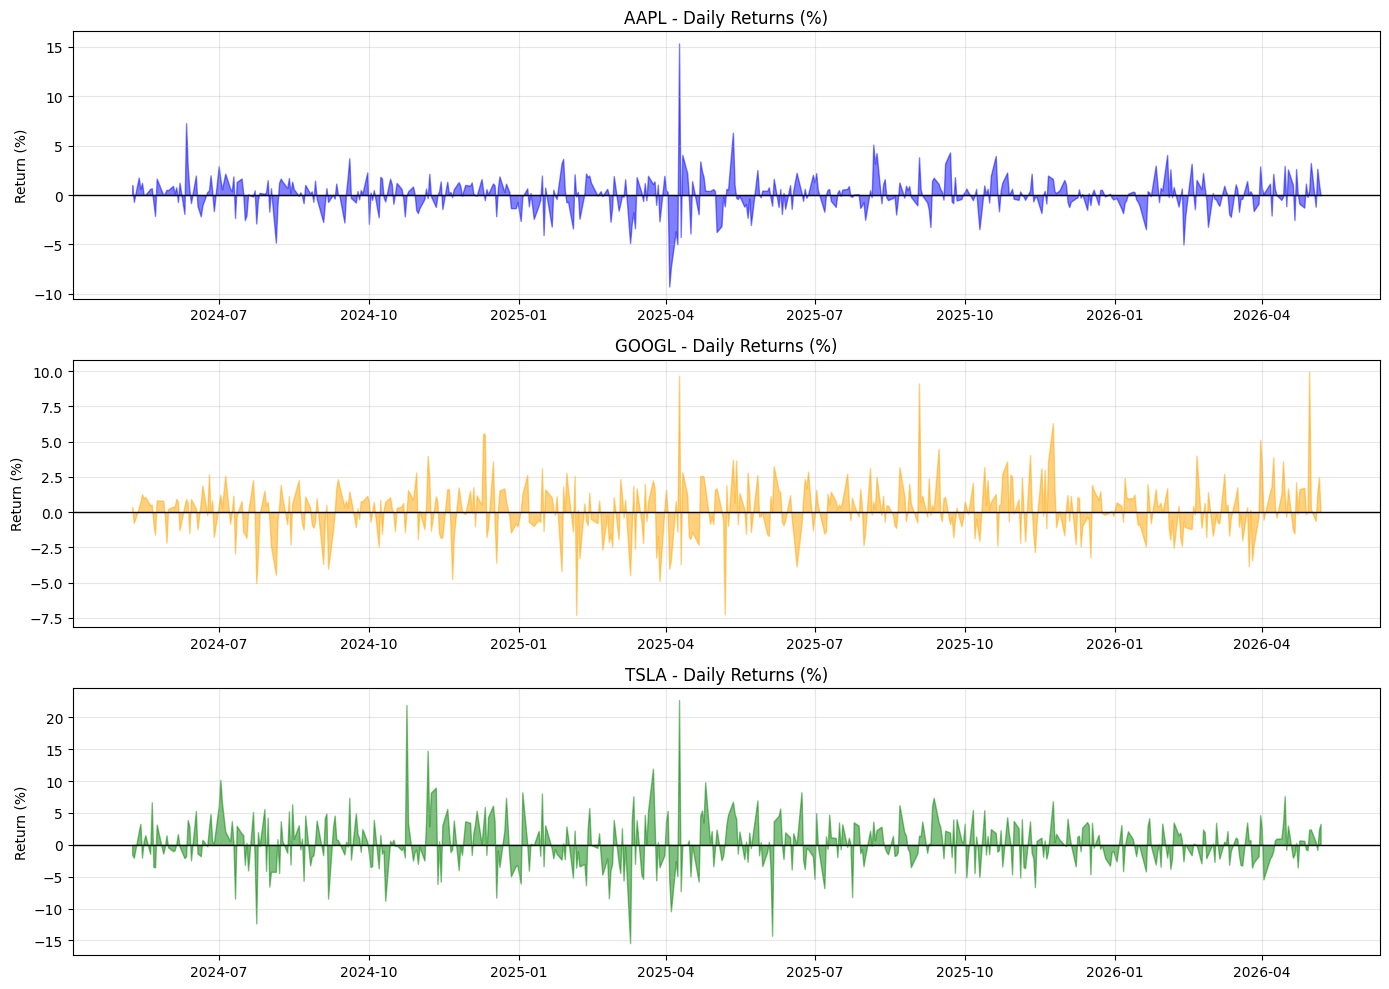

Volatility (Standard Deviation of Daily Returns):
Ticker
AAPL     1.78
GOOGL    1.90
TSLA     3.84
dtype: float64

Average Daily Return (%):
Ticker
AAPL     0.108
GOOGL    0.190
TSLA     0.244
dtype: float64


In [7]:
daily_returns = df.pct_change().dropna() * 100
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
colors = ['blue', 'orange', 'green']
companies = ['AAPL', 'GOOGL', 'TSLA']
for i, (company, color) in enumerate(zip(companies, colors)):
    axes[i].fill_between(daily_returns.index, 
                          daily_returns[company], 
                          color=color, alpha=0.5)
    axes[i].set_title(f'{company} - Daily Returns (%)')
    axes[i].set_ylabel('Return (%)')
    axes[i].axhline(y=0, color='black', linewidth=1)
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('daily_returns.png', dpi=150)
plt.show()
print("Volatility (Standard Deviation of Daily Returns):")
print(daily_returns.std().round(2))
print("\nAverage Daily Return (%):")
print(daily_returns.mean().round(3))

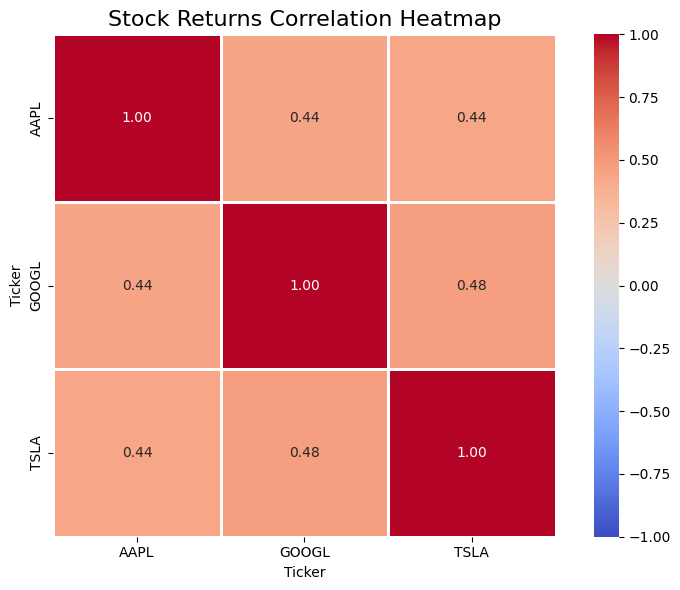

Correlation Matrix:
Ticker  AAPL  GOOGL  TSLA
Ticker                   
AAPL    1.00   0.44  0.44
GOOGL   0.44   1.00  0.48
TSLA    0.44   0.48  1.00


In [8]:
correlation = daily_returns.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt='.2f', 
            cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=2)
plt.title('Stock Returns Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.savefig('correlation.png', dpi=150)
plt.show()
print("Correlation Matrix:")
print(correlation.round(2))